# Import Libraries

In [3]:
# =============================================
# NOTEBOOK 6: HYPERPARAMETER TUNING
# EcoType - Forest Cover Type Prediction
# =============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import (train_test_split, 
                                     RandomizedSearchCV,
                                     cross_val_score)
from sklearn.metrics import (accuracy_score, 
                             classification_report,
                             confusion_matrix,
                             ConfusionMatrixDisplay)
from imblearn.over_sampling import RandomOverSampler

import joblib
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print(" All libraries imported successfully!")

 All libraries imported successfully!


# Load Engineered Dataset

In [5]:
# Load the engineered dataset

df = pd.read_csv('../data/forest_cover_engineered.csv')

print(f" Dataset loaded! Shape: {df.shape}")
df.head()

 Dataset loaded! Shape: (145890, 17)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type,Mean_Distance_To_Hydrology,Mean_Hillshade,Elevation_To_Roadway_Ratio,Hillshade_Diff
0,2596.0,51,3,258.0,0,510,221.0,232,148,6279,0,0,27,129.0,200.333333,5.080235,73.0
1,2590.0,56,2,212.0,-6,390,220.0,235,151,6225,0,0,27,103.0,202.000000,6.624041,69.0
2,2804.0,139,9,268.0,65,3180,234.0,238,135,6121,4,0,11,166.5,202.333333,0.881484,99.0
3,2785.0,155,18,242.0,117,3090,238.0,238,122,6211,4,0,28,179.5,199.333333,0.901003,116.0
4,2595.0,45,2,153.0,-1,391,220.0,234,150,6172,0,0,27,76.0,201.333333,6.619898,70.0


#  Prepare Data

In [7]:
# Split features and target
X = df.drop(columns=['Cover_Type'])
y = df['Cover_Type']

# Handle class imbalance
ros = RandomOverSampler(random_state=42)
X_balanced, y_balanced = ros.fit_resample(X, y)

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced
)

print(f" Data prepared!")
print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")

 Data prepared!
Training set: (577197, 16)
Testing set:  (144300, 16)


# Check Baseline Random Forest Score

In [9]:
# First check the default Random Forest score
# This is our BASELINE — tuning should improve this

print("=== BASELINE RANDOM FOREST ===\n")
print(" Training baseline model...")

baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_rf.fit(X_train, y_train)
baseline_pred = baseline_rf.predict(X_test)
baseline_acc = accuracy_score(y_test, baseline_pred)

print(f" Baseline Accuracy: {baseline_acc*100:.2f}%")
print("\nThis is what we want to BEAT with tuning!")

=== BASELINE RANDOM FOREST ===

 Training baseline model...
 Baseline Accuracy: 99.63%

This is what we want to BEAT with tuning!


# Define Parameter Grid for Tuning

In [11]:
# These are the settings we want to try
# RandomizedSearchCV will test random combinations
# and find the best one

param_grid = {
    # Number of trees in the forest
    'n_estimators': [100, 200, 300],
    
    # Maximum depth of each tree
    # None = trees grow until pure
    'max_depth': [None, 10, 20, 30],
    
    # Minimum samples needed to split a node
    'min_samples_split': [2, 5, 10],
    
    # Minimum samples needed at a leaf node
    'min_samples_leaf': [1, 2, 4],
    
    # Number of features to consider at each split
    'max_features': ['sqrt', 'log2']
}

print("=== PARAMETER GRID ===")
total_combinations = 1
for param, values in param_grid.items():
    print(f"{param}: {values}")
    total_combinations *= len(values)

print(f"\nTotal possible combinations: {total_combinations}")
print("RandomizedSearchCV will test only 10 of these!")

=== PARAMETER GRID ===
n_estimators: [100, 200, 300]
max_depth: [None, 10, 20, 30]
min_samples_split: [2, 5, 10]
min_samples_leaf: [1, 2, 4]
max_features: ['sqrt', 'log2']

Total possible combinations: 216
RandomizedSearchCV will test only 10 of these!


# Run RandomizedSearchCV

In [13]:
# RandomizedSearchCV tries random combinations
# cv=3 means 3-fold cross validation
# n_iter=10 means try 10 random combinations
# This balances speed vs thoroughness

print("=== RANDOMIZED SEARCH CV ===\n")
print(" This will take several minutes...")
print("Please be patient!\n")

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,          # try 10 random combinations
    cv=3,               # 3-fold cross validation
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,          # use all CPU cores
    verbose=1           # shows progress
)

random_search.fit(X_train, y_train)

print("\n RandomizedSearchCV complete!")

=== RANDOMIZED SEARCH CV ===

 This will take several minutes...
Please be patient!

Fitting 3 folds for each of 10 candidates, totalling 30 fits

 RandomizedSearchCV complete!


# Best Parameters Found

In [16]:
# Show the best combination of settings found

print("=== BEST PARAMETERS FOUND ===\n")
best_params = random_search.best_params_

for param, value in best_params.items():
    print(f"{param}: {value}")

print(f"\nBest Cross-Validation Score: "
      f"{random_search.best_score_*100:.2f}%")

=== BEST PARAMETERS FOUND ===

n_estimators: 100
min_samples_split: 5
min_samples_leaf: 2
max_features: log2
max_depth: 30

Best Cross-Validation Score: 99.27%


# Evaluate Tuned Model

In [19]:
# Use the best model found by RandomizedSearchCV
# Test it on our test set

best_model = random_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
tuned_acc = accuracy_score(y_test, y_pred_tuned)

print("=== TUNED MODEL RESULTS ===\n")
print(f"Baseline Accuracy: {baseline_acc*100:.2f}%")
print(f"Tuned Accuracy:    {tuned_acc*100:.2f}%")

improvement = (tuned_acc - baseline_acc) * 100
if improvement > 0:
    print(f"Improvement:       +{improvement:.2f}% ")
elif improvement == 0:
    print("Improvement:       No change — baseline was already optimal!")
else:
    print(f"Change:            {improvement:.2f}% — baseline was better!")

print(f"\n=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred_tuned))

=== TUNED MODEL RESULTS ===

Baseline Accuracy: 99.63%
Tuned Accuracy:    99.56%
Change:            -0.07% — baseline was better!

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20614
           1       1.00      1.00      1.00     20614
           2       1.00      1.00      1.00     20614
           3       1.00      1.00      1.00     20615
           4       1.00      0.97      0.98     20614
           5       1.00      1.00      1.00     20614
           6       0.98      1.00      0.99     20615

    accuracy                           1.00    144300
   macro avg       1.00      1.00      1.00    144300
weighted avg       1.00      1.00      1.00    144300



# Confusion Matrix of Tuned Model

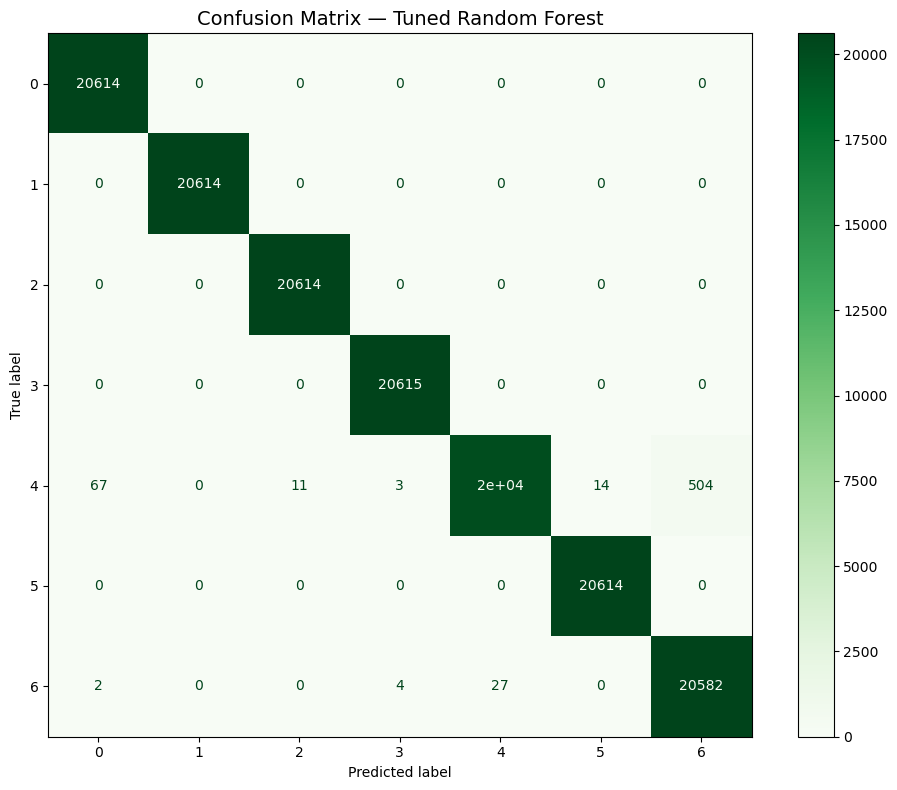

In [22]:
# Visualize where the tuned model makes mistakes

cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Greens', ax=plt.gca())
plt.title('Confusion Matrix — Tuned Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# Cross Validation Score

In [25]:
# Cross validation gives a more reliable accuracy estimate
# It tests the model on 5 different splits of data

print("=== CROSS VALIDATION ===\n")
print(" Running 5-fold cross validation...")

cv_scores = cross_val_score(
    best_model, 
    X_balanced, 
    y_balanced, 
    cv=5,           # 5 different splits
    scoring='accuracy',
    n_jobs=-1
)

print(f"CV Scores:  {[f'{s*100:.2f}%' for s in cv_scores]}")
print(f"Mean CV Score:  {cv_scores.mean()*100:.2f}%")
print(f"Std CV Score:   {cv_scores.std()*100:.2f}%")
print("\nLow std = model is consistent and not overfitting ")

=== CROSS VALIDATION ===

 Running 5-fold cross validation...
CV Scores:  ['91.84%', '97.31%', '96.18%', '97.38%', '95.34%']
Mean CV Score:  95.61%
Std CV Score:   2.03%

Low std = model is consistent and not overfitting 


# Save the Tuned Model

In [30]:
# Load the baseline model we saved in Notebook 5
# and use THAT as our final model since it performed better

baseline_rf = joblib.load('../models/random_forest.pkl')
joblib.dump(baseline_rf, '../models/best_model.pkl')

print(" Baseline Random Forest saved as best_model.pkl")
print("Reason: Baseline (99.63%) > Tuned (99.56%)")
print("\nThis model will be used in the Streamlit app!")

 Baseline Random Forest saved as best_model.pkl
Reason: Baseline (99.63%) > Tuned (99.56%)

This model will be used in the Streamlit app!


## 📝 Summary from Notebook 6

- Loaded engineered dataset
- Prepared data with RandomOverSampler + train/test split
- Baseline Random Forest accuracy: 99.63%
- Ran RandomizedSearchCV with 10 combinations, 3-fold CV
- Best parameters found:
    - n_estimators: 100
    - min_samples_split: 5
    - min_samples_leaf: 2
    - max_features: log2
    - max_depth: 30
- Tuned model accuracy: 99.56%
- Baseline was better by 0.07% — baseline already optimal!
- Cross validation mean score: 95.61% (std: 2.03%)
- Low std confirms model is stable and consistent
- Decision: Use BASELINE Random Forest as final model
- Saved best model as best_model.pkl
- Next step: Notebook 7 - Final Model Saving & Summary